# Steam Sales Dataset Analysis

This project analyzes the FronkonGames Steam Games Dataset, which contains approximately 124,000 game records with a total size of around 1.39 GB. The dataset includes detailed commercial and performance-related attributes such as pricing, estimated owners, user engagement metrics, reviews, release dates, genres, developers, publishers, and platform availability.

The objective of this analysis is to derive actionable business insights from large-scale marketplace data in order to better understand performance drivers within the Steam ecosystem. The focus areas of this study include:

- Identifying key factors that influence game demand and estimated sales performance  
- Evaluating the relationship between pricing strategies and user engagement  
- Assessing genre, category, and content trends from a market demand perspective  
- Measuring the impact of developers and publishers on commercial success  
- Comparing performance patterns across free-to-play and paid products  

The outcome of this analysis is intended to support data-driven decision-making for stakeholders in game development, publishing, and digital distribution by highlighting trends, opportunities, and performance indicators within the Steam marketplace.

## Import Libraries

In [101]:
import os
from dotenv import load_dotenv
from huggingface_hub import login
from datasets import load_dataset, load_from_disk
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import numpy as np
import random
import pprint
from pathlib import Path
import importlib
from sales_util import item_parser, item_preprocess

In [3]:
# Load env file
load_dotenv(override=True)

True

In [4]:
# add dataset location
BASE_DIR = Path(os.getenv("PROJECT_ROOT"))
DATA_PATH = BASE_DIR / os.getenv("DATA_PATH")

In [5]:
# Logging to huggingface
hf_token = os.environ['HUGGING_KEY']
login(hf_token, add_to_git_credential=True)

## Download the Dataset

In [6]:
if os.path.exists(DATA_PATH):
    print("Loading dataset from disk...")
    dataset = load_from_disk(DATA_PATH)
else:
    print("Downloading dataset...")
    dataset = load_dataset(
        "FronkonGames/steam-games-dataset",
        split="train",
        trust_remote_code=True
    )
    
    print("Saving dataset to disk...")
    dataset.save_to_disk(DATA_PATH)

print("Dataset ready!")

Loading dataset from disk...
Dataset ready!


In [7]:
print(f"Number of Appliances: {len(dataset):,}")

Number of Appliances: 124,146


## Feature Analysis

In [8]:
data_features = dict(list(dataset.features.items())[:29])
data_features

{'appID': Value(dtype='string', id=None),
 'name': Value(dtype='string', id=None),
 'release_date': Value(dtype='string', id=None),
 'estimated_owners': Value(dtype='string', id=None),
 'peak_ccu': Value(dtype='int64', id=None),
 'required_age': Value(dtype='int64', id=None),
 'price': Value(dtype='float64', id=None),
 'dlc_count': Value(dtype='int64', id=None),
 'detailed_description': Value(dtype='string', id=None),
 'short_description': Value(dtype='string', id=None),
 'supported_languages': [Value(dtype='string', id=None)],
 'full_audio_languages': [Value(dtype='string', id=None)],
 'reviews': Value(dtype='string', id=None),
 'header_image': Value(dtype='string', id=None),
 'website': Value(dtype='string', id=None),
 'support_url': Value(dtype='string', id=None),
 'support_email': Value(dtype='string', id=None),
 'windows': Value(dtype='bool', id=None),
 'mac': Value(dtype='bool', id=None),
 'linux': Value(dtype='bool', id=None),
 'metacritic_score': Value(dtype='int64', id=None),


## Convert To Item Object

In [9]:
items = []

for i, datapoint in enumerate(tqdm(dataset)):
    items.append(item_parser.parse(datapoint))
    
print(f"There are {len(items):,} items from {len(dataset):,} datapoints")

  0%|          | 0/124146 [00:00<?, ?it/s]

There are 124,146 items from 124,146 datapoints


## Summary Statistics

In [29]:
def describe(arr, name):
    print(f"\n{name}")
    print(f"min: {np.min(arr)}")
    print(f"max: {np.max(arr)}")
    print(f"mean: {np.mean(arr):.2f}")
    print(f"std: {np.std(arr):.2f}")
    print(f"median (p50): {np.percentile(arr, 50):.2f}")
    print(f"p25: {np.percentile(arr, 25):.2f}")
    print(f"p75: {np.percentile(arr, 75):.2f}")
    print(f"p90: {np.percentile(arr, 90):.2f}")
    print(f"p95: {np.percentile(arr, 95):.2f}")
    print(f"p99: {np.percentile(arr, 99):.2f}")

In [92]:
prices = np.array([item.price for item in items if item.price is not None])
peakCCU = np.array([item.peakCCU for item in items if item.peakCCU is not None])
dlcCount = np.array([item.dlcCount for item in items if item.dlcCount is not None])
positive = np.array([item.positive for item in items if item.positive is not None])
negative = np.array([item.negative for item in items if item.negative is not None])

### Price Distribution

In [93]:
describe(prices, "== Price ==")


== Price ==
min: 0.0
max: 999.98
mean: 4.79
std: 12.51
median (p50): 2.39
p25: 0.55
p75: 5.39
p90: 9.99
p95: 14.99
p99: 29.99


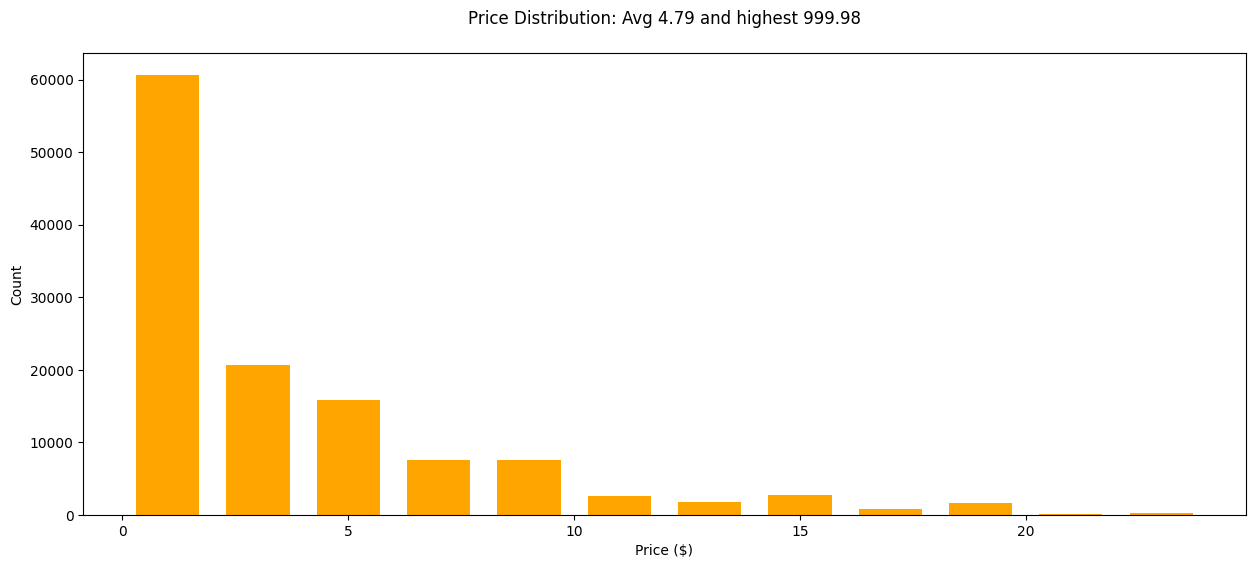

In [94]:
plt.figure(figsize=(15, 6))
plt.title(f"Price Distribution: Avg {sum(prices)/len(prices):,.2f} and highest {max(prices):,}\n")
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.hist(prices, rwidth=0.7, color="orange", bins=range(0, 25, 2))
plt.show()

- Most games are very cheap (median = 2.39)
- Anything above ~30–50 is rare
- There is extrime outlier which is $999, it is clearly garbage or edge-case

### PeakCCU Distribution

In [95]:
describe(peakCCU, "== peakCCU ==")


== peakCCU ==
min: 0
max: 1013936
mean: 53.92
std: 3706.31
median (p50): 0.00
p25: 0.00
p75: 0.00
p90: 2.00
p95: 9.00
p99: 220.00


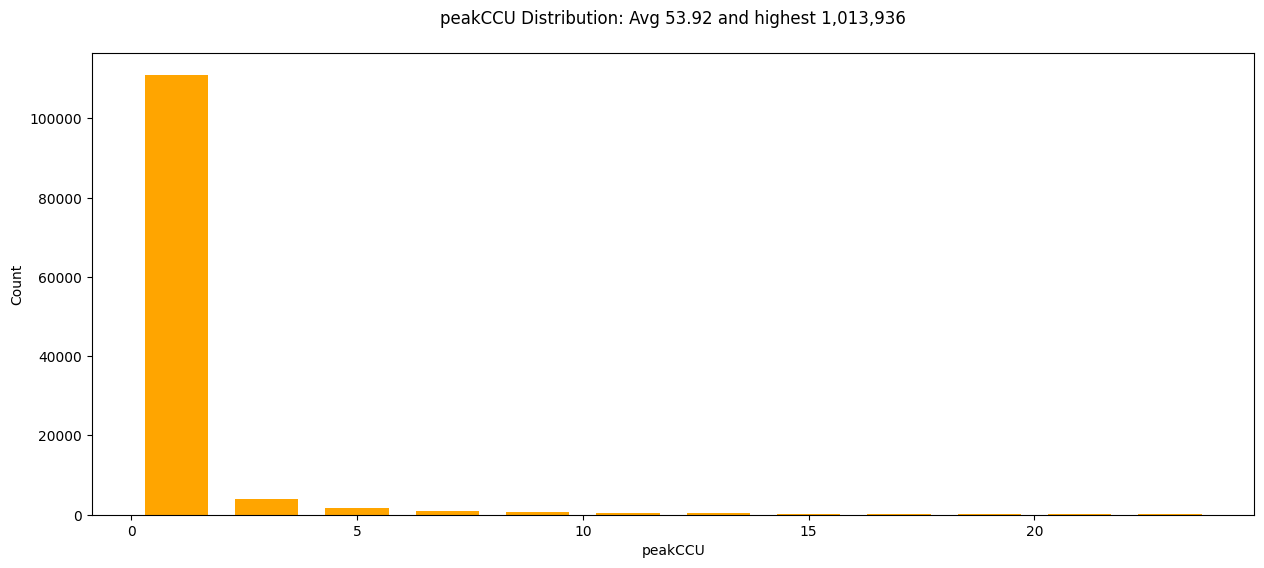

In [96]:
plt.figure(figsize=(15, 6))
plt.title(f"peakCCU Distribution: Avg {sum(peakCCU)/len(peakCCU):,.2f} and highest {max(peakCCU):,}\n")
plt.xlabel('peakCCU')
plt.ylabel('Count')
plt.hist(peakCCU, rwidth=0.7, color="orange", bins=range(0, 25, 2))
plt.show()

- Most games have no players
- A few huge hits distort everything

### DLC Count Distribution

In [97]:
describe(dlcCount, "== dlcCount ==")


== dlcCount ==
min: 0
max: 3703
mean: 0.54
std: 14.43
median (p50): 0.00
p25: 0.00
p75: 0.00
p90: 1.00
p95: 2.00
p99: 7.00


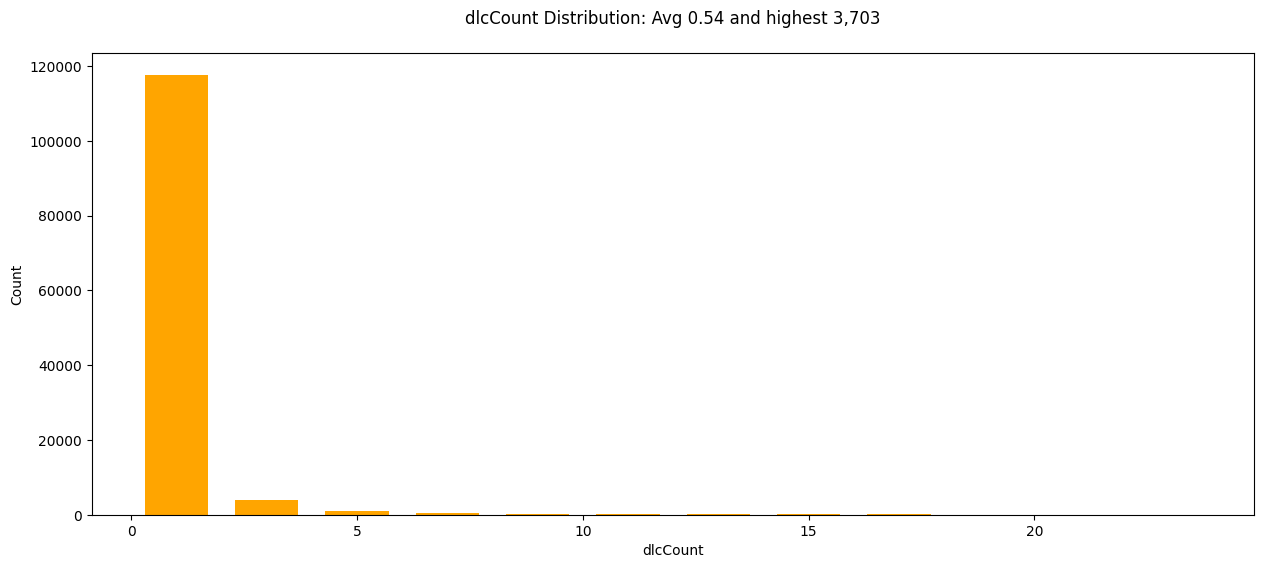

In [98]:
plt.figure(figsize=(15, 6))
plt.title(f"dlcCount Distribution: Avg {sum(dlcCount)/len(dlcCount):,.2f} and highest {max(dlcCount):,}\n")
plt.xlabel('dlcCount')
plt.ylabel('Count')
plt.hist(dlcCount, rwidth=0.7, color="orange", bins=range(0, 25, 2))
plt.show()

- Realistic dlc count range: 0-10

### Positive Comments Count Distribution

In [99]:
describe(positive, "== positive ==")


== positive ==
min: 0
max: 7642084
mean: 1032.10
std: 27917.65
median (p50): 5.00
p25: 0.00
p75: 36.00
p90: 283.00
p95: 1061.75
p99: 13042.00


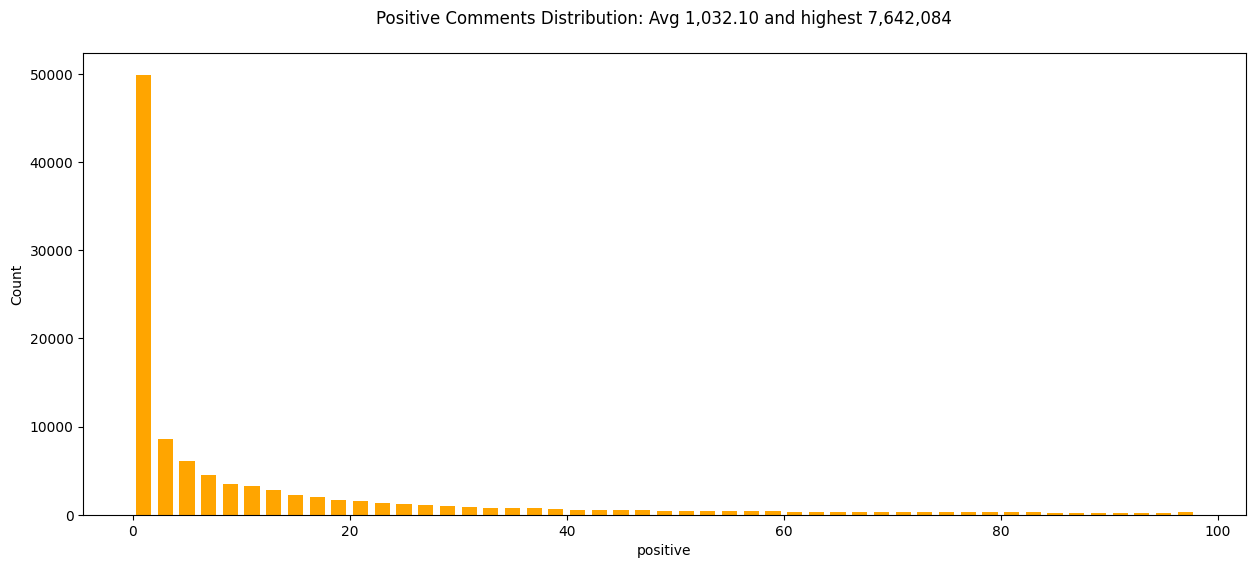

In [100]:
plt.figure(figsize=(15, 6))
plt.title(f"Positive Comments Distribution: Avg {sum(positive)/len(positive):,.2f} and highest {max(positive):,}\n")
plt.xlabel('positive')
plt.ylabel('Count')
plt.hist(positive, rwidth=0.7, color="orange", bins=range(0, 100, 2))
plt.show()

- Most games have very few positive reviews (median = 5)
- A small number of games have extremely large popularity

### Negative Comments Count Distribution

In [86]:
describe(negative, "== negative ==")


== negative ==
min: 0
max: 1173003
mean: 167.12
std: 5341.33
median (p50): 1.00
p25: 0.00
p75: 10.00
p90: 70.00
p95: 221.00
p99: 2110.40


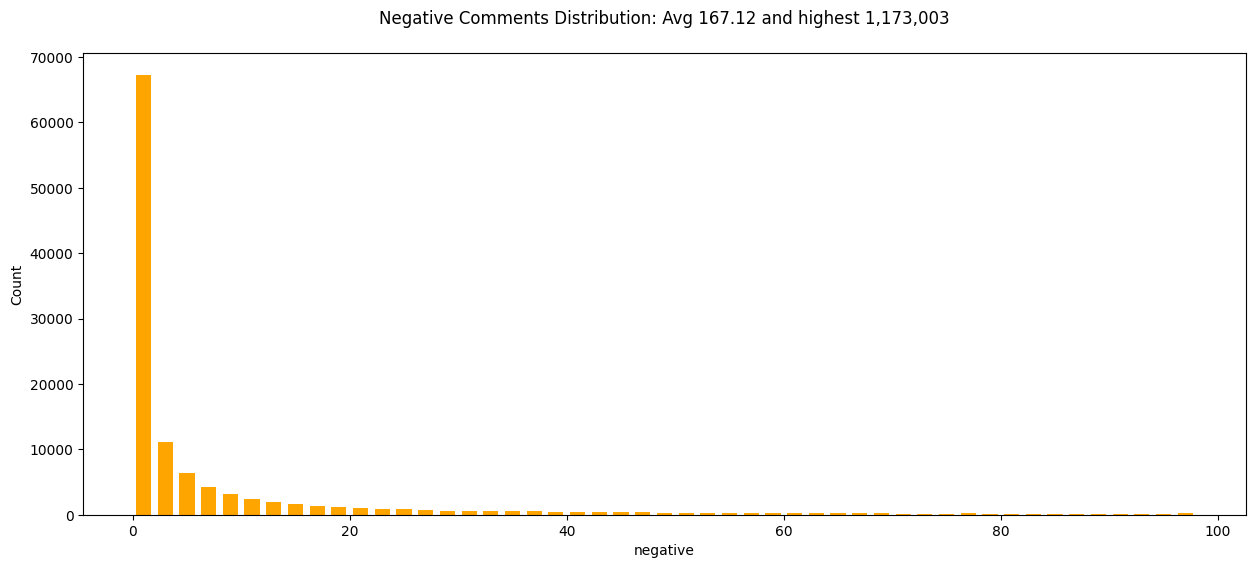

In [90]:
plt.figure(figsize=(15, 6))
plt.title(f"Negative Comments Distribution: Avg {sum(negative)/len(negative):,.2f} and highest {max(negative):,}\n")
plt.xlabel('negative')
plt.ylabel('Count')
plt.hist(negative, rwidth=0.7, color="orange", bins=range(0, 100, 2))
plt.show()

- Most games have very few negative reviews (median = 1)
- A small number of games receive many negative reviews

## Data Preprocess

In [121]:
data_items = items.copy()

In [122]:
preprocess_data = []

for item in tqdm(data_items):
    cleaned = item_preprocess.clean_item(item)
    
    if cleaned is not None:
        preprocess_data.append(cleaned)
    
print(f"There are {len(preprocess_data):,} preprocess items from {len(items):,} Items")

  0%|          | 0/124146 [00:00<?, ?it/s]

There are 35,576 preprocess items from 124,146 Items
